<a href="https://colab.research.google.com/github/shriyam943/CNN/blob/main/Kmean_marketing_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as nm
import matplotlib.pyplot as mtp
import pandas as pd


In [ ]:
dataset = pd.read_csv('marketing_campaign.csv',sep = '\t')

In [ ]:
dataset.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [ ]:
x = dataset[['Recency','MntWines']]

In [ ]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x = sc.fit_transform(x)

In [ ]:
from sklearn.cluster import KMeans

wcss_list= []

In [ ]:
for i in range(1, 11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state= 42)
  kmeans.fit(x)
  wcss_list.append(kmeans.inertia_)

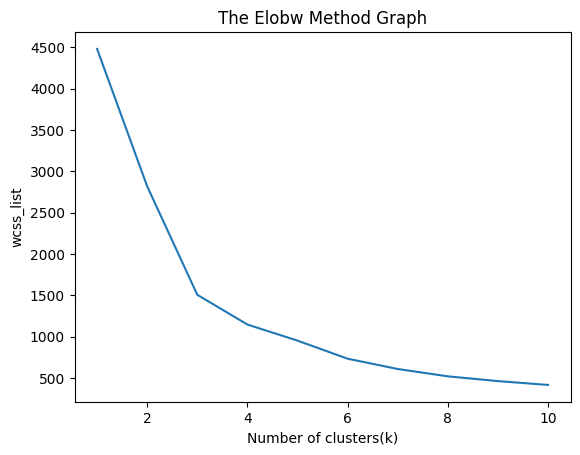

In [ ]:
mtp.plot(range(1, 11), wcss_list)

mtp.title('The Elobw Method Graph')

mtp.xlabel('Number of clusters(k)')

mtp.ylabel('wcss_list')

mtp.show()

In [ ]:
kmeans = KMeans(n_clusters=4, init='k-means++', random_state= 42)

y_pred= kmeans.fit_predict(x)

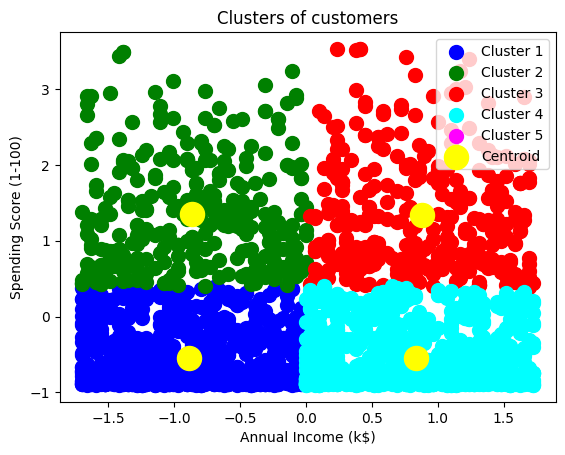

In [ ]:
mtp.scatter(x[y_pred == 0, 0],x[y_pred == 0, 1], s = 100, c = 'blue', label = 'Cluster 1')
mtp.scatter(x[y_pred == 1, 0],x[y_pred == 1, 1], s = 100, c = 'green', label = 'Cluster 2')
mtp.scatter(x[y_pred == 2, 0],x[y_pred == 2, 1], s = 100, c = 'red', label = 'Cluster 3')
mtp.scatter(x[y_pred == 3, 0],x[y_pred == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
mtp.scatter(x[y_pred == 4, 0],x[y_pred == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
mtp.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroid')
mtp.title('Clusters of customers')

mtp.xlabel('Annual Income (k$)')

mtp.ylabel('Spending Score (1-100)')

mtp.legend()

mtp.show()